# Deblur a spiral acquisition that ran off resonance

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrdistortion/blob/main/examples/03-spiral_deblurring.ipynb)

A spiral reads k-space over milliseconds, so off-resonance accrues phase along
the readout and the image blurs. The transfer is factorised once from the
trajectory's time map into a few separable terms; correcting an image is then a
handful of transforms whose cost does not grow with how finely the field is
resolved.

The blur here is simulated exactly, by summing over the distinct values of a
quantised field map, so the corrected image can be compared against truth.

In [1]:
try:
    import mrdistortion  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "mrdistortion", "matplotlib"],
        check=True,
    )

In [2]:
# The BrainWeb helper lives beside this example in the repository; fetch it if
# this is running somewhere that only has the notebook.
import urllib.request
from pathlib import Path

if not Path("_brainweb.py").exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/FiRMLAB-Pisa/mrdistortion/main/"
        "examples/_brainweb.py",
        "_brainweb.py",
    )

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrdistortion as mrd

SIZE = 256
READOUT_S = 20e-3
BAND_HZ = 260.0
TERMS = 56


def variable_density_arm(samples: int = 1500) -> np.ndarray:
    """One centre-out arm whose radius grows as a fractional power of time."""
    time = np.linspace(0.0, 1.0, samples)
    radius = time**0.6
    angle = 40 * np.pi * time
    return np.stack([radius * np.cos(angle), radius * np.sin(angle)], axis=1)


def scene(size: int):
    """A BrainWeb slice, the field its own tissue makes, and the head."""
    try:
        from _brainweb import brain_and_field
    except ImportError:  # pragma: no cover
        raise SystemExit("this example needs brainweb-dl and scipy") from None
    image, field, mask = brain_and_field(slice_index=60, size=size)
    rows, columns = np.mgrid[0:size, 0:size] / (size / 2) - 1
    # The smooth object phase any acquisition carries.
    return image * np.exp(1j * 0.7 * (columns + 0.5 * rows)), field, mask

In [3]:
timing = mrd.ReadoutTiming.from_trajectory(variable_density_arm(), duration=READOUT_S)
transfer = mrd.fit_transfer(timing, band=BAND_HZ, terms=TERMS)
print(
    f"{transfer.terms} separable terms, error {transfer.error(timing):.4f}, "
    f"amplification {transfer.amplification:.0f}"
)

axis = np.fft.fftfreq(SIZE) * 2
squared = axis[:, None] ** 2 + axis[None, :] ** 2
disc = squared <= 1.0
times = np.interp(np.clip(squared, 0, 1), timing.squared_radius, timing.times)

truth, field, mask = scene(SIZE)
ideal = np.fft.ifft2(np.fft.fft2(truth) * disc)

56 separable terms, error 0.0012, amplification 87


/home/mcencini/mrdistortion/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


field in the head +24 +- 62 Hz, up to +538, over a 20 ms readout
error: blurred 0.1637 -> corrected 0.0922


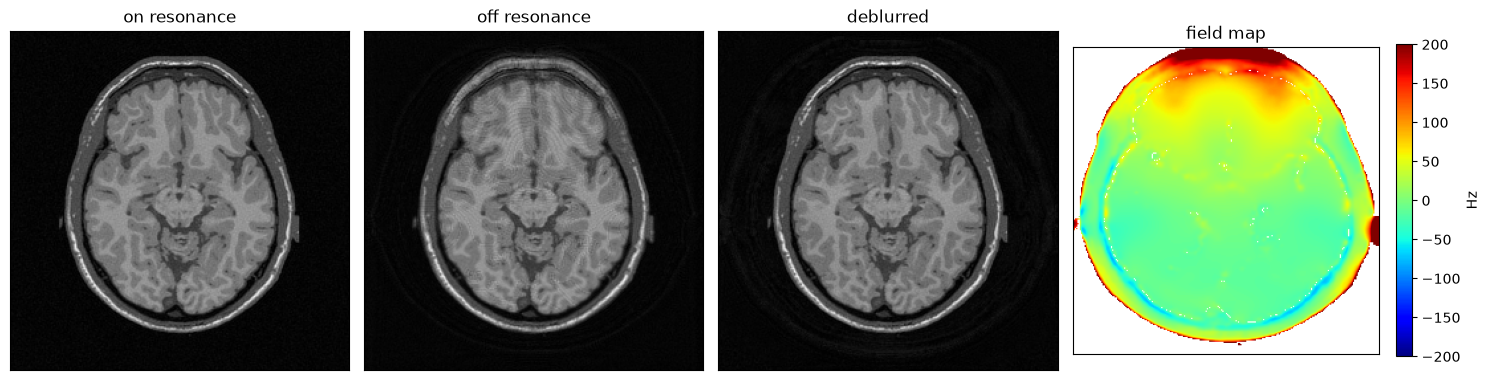

In [4]:
# Blur exactly, by summing over the distinct values of a quantised field.
# Coarse quantisation shows up as concentric rings, so use plenty of levels.
levels = np.linspace(field.min(), field.max(), 200)
quantised = levels[np.abs(field[..., None] - levels).argmin(-1)]
blurred = np.zeros_like(ideal)
for value in np.unique(quantised):
    selected = np.fft.fft2(truth * (quantised == value)) * disc
    blurred += np.fft.ifft2(selected * np.exp(2j * np.pi * value * READOUT_S * times))

corrected = mrd.deblur(
    torch.from_numpy(blurred), torch.from_numpy(quantised), transfer
).numpy()

error = lambda x: np.linalg.norm(x - ideal) / np.linalg.norm(ideal)
print(
    f"field in the head {field[mask].mean():+.0f} +- {field[mask].std():.0f} Hz, "
    f"up to {field[mask].max():+.0f}, over a {READOUT_S * 1e3:.0f} ms readout"
)
print(f"error: blurred {error(blurred):.4f} -> corrected {error(corrected):.4f}")

figure, axes = plt.subplots(1, 4, figsize=(15, 4.2))
top = np.abs(ideal).max()
for axis_, data, title in (
    (axes[0], np.abs(ideal), "on resonance"),
    (axes[1], np.abs(blurred), "off resonance"),
    (axes[2], np.abs(corrected), "deblurred"),
):
    axis_.imshow(data, cmap="gray", vmin=0, vmax=top)
    axis_.set_title(title)
    axis_.set_xticks([])
    axis_.set_yticks([])
shown = axes[3].imshow(np.where(mask, field, np.nan), cmap="jet", vmin=-200, vmax=200)
axes[3].set_title("field map")
axes[3].set_xticks([])
axes[3].set_yticks([])
figure.colorbar(shown, ax=axes[3], fraction=0.046, label="Hz")
figure.tight_layout()
figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "spiral_deblurring.png", dpi=110)